In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("epl2020.csv")
print(df)

     Unnamed: 0 h_a        xG       xGA      npxG     npxGA  deep  \
0             1   h  2.234560  0.842407  2.234560  0.842407    11   
1             2   a  0.842407  2.234560  0.842407  2.234560     5   
2             3   a  3.183770  1.200300  2.422640  1.200300     9   
3             4   h  1.200300  3.183770  1.200300  2.422640     1   
4             5   h  1.340990  1.598640  1.340990  1.598640     4   
..          ...  ..       ...       ...       ...       ...   ...   
571         572   a  0.445922  2.028830  0.445922  2.028830     3   
572         573   a  0.585469  1.738900  0.585469  1.738900     2   
573         574   h  1.738900  0.585469  1.738900  0.585469     3   
574         575   a  0.672448  2.412390  0.672448  1.651220     2   
575         576   h  2.412390  0.672448  1.651220  0.672448     8   

     deep_allowed  scored  missed  ...  AF.x AC.x AY.x  AR.x  B365H.x  \
0               5       4       1  ...     9    2    2     0     1.14   
1              11       1

In [ ]:
#Objective: Determine the factors contributed the most to team success in the 2019/2020 premier league season 

In [4]:
#Data cleaning by checking for any duplicates
df = df.drop_duplicates()

In [4]:
#Standardise some column names for better understanding 
df.rename(columns={"loses":"losses"}, inplace = True)
df.rename(columns={"teamId":"teamName"}, inplace = True)


In [8]:
#Exploring all columns to understand what I am working with
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 45 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    576 non-null    int64  
 1   h_a           576 non-null    object 
 2   xG            576 non-null    float64
 3   xGA           576 non-null    float64
 4   npxG          576 non-null    float64
 5   npxGA         576 non-null    float64
 6   deep          576 non-null    int64  
 7   deep_allowed  576 non-null    int64  
 8   scored        576 non-null    int64  
 9   missed        576 non-null    int64  
 10  xpts          576 non-null    float64
 11  result        576 non-null    object 
 12  date          576 non-null    object 
 13  wins          576 non-null    int64  
 14  draws         576 non-null    int64  
 15  losses        576 non-null    int64  
 16  pts           576 non-null    int64  
 17  npxGD         576 non-null    float64
 18  teamName      576 non-null    

In [5]:
#Which team scored the most goals 
df.pivot_table(values="tot_goal",index="teamName",aggfunc=max).sort_values(by= "tot_goal",ascending=False)
#Man City scored the most goals, but still ended up getting second, this means that goals is not the only factor needed to take into consideration

C:\Users\Ayomiposi\AppData\Local\Temp\ipykernel_9460\1479882267.py:2: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.pivot_table(values="tot_goal",index="teamName",aggfunc=max).sort_values(by= "tot_goal",ascending=False)


,tot_goal
teamName,
Man City,68
Liverpool,66
Leicester,58
Chelsea,51
Tottenham,47
Man Utd,44
Wolves,41
Arsenal,40
Everton,37


In [6]:
#Which team conceded the most goals 
df.pivot_table(values="tot_con",index="teamName",aggfunc=max).sort_values(by= "tot_con",ascending=False)
#Goals conceded had an impact on results, because liverpool managed to conceded a significant 10 less goals than Man City, meaning defensive strength is just as important as goals scored, possibly, even more important 

C:\Users\Ayomiposi\AppData\Local\Temp\ipykernel_9460\2253209950.py:2: FutureWarning: The provided callable <built-in function max> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.pivot_table(values="tot_con",index="teamName",aggfunc=max).sort_values(by= "tot_con",ascending=False)


,tot_con
teamName,
Aston Villa,56
Norwich,52
Southampton,52
West Ham,50
Bournemouth,47
Everton,46
Watford,44
Newcastle United,41
Brighton,40


In [20]:
#Which team had the highest xG
df.pivot_table(values="xG",index="teamName").sort_values(by= "xG",ascending=False) 
#Man City had the highest xG with the highest goals Scored while being in the bottom five for least goals conceded but ultimately liverpool were just as superior in  every stat and way more superior defensively.

,xG
teamName,
Man City,2.609960
Liverpool,2.104402
Chelsea,1.934192
Man Utd,1.691825
Leicester,1.647321
Everton,1.606202
Wolves,1.538778
Southampton,1.434291
Burnley,1.391961


In [5]:
# Calculate the correlation between total points and XG,xGA,total goals, total conceded 
team = df.groupby("teamName").max(numeric_only=True)
correlation = team.corr()["tot_points"].sort_values(ascending=False)
print(correlation)
#From the conclusion there was a negative correlation between xGA and total points, this means that teams with a lower xGA generally had a more points, which makes logical sense.
#The existence of a negative correlation between total goals conceded and total points also makes logical sense, with lower goals equalling to higher points generally.
#There is a high correlation between total points and goals scored with a correlation of 0.84 approximately, it shows that goals play a huge factor in securing points
#Between xG and points, there is a moderate correlation indicating a slight chance that expected goal had any relevance to total points.

tot_points      1.000000
tot_goal        0.841858
allowed_ppda    0.653323
xpts            0.607021
npxG            0.606925
npxGD           0.584821
scored          0.512252
xG              0.506136
deep            0.501273
HST.x           0.462898
HC.x            0.350497
AS.x            0.258459
AC.x            0.185030
HtrgPerc        0.169467
HR.x            0.164613
matchtime       0.122939
AF.x            0.093425
AtrgPerc        0.079232
Unnamed: 0      0.066451
HS.x           -0.050535
AST.x          -0.056152
round          -0.061383
B365D.x        -0.096943
AY.x           -0.112621
B365A.x        -0.115281
B365H.x        -0.150389
HY.x           -0.280875
HF.x           -0.288865
AR.x           -0.424100
ppda_cal       -0.458049
npxGA          -0.458858
deep_allowed   -0.464818
missed         -0.497860
xGA            -0.520624
tot_con        -0.817611
wins                 NaN
draws                NaN
losses               NaN
pts                  NaN
Name: tot_points, dtype: 

In [13]:
#Checking for final points earned 
df.groupby("teamName")["tot_points"].max().sort_values(ascending=False)

teamName
Liverpool           82
Man City            57
Leicester           53
Chelsea             48
Man Utd             45
Sheffield United    43
Wolves              43
Tottenham           41
Arsenal             40
Crystal Palace      39
Burnley             39
Everton             37
Newcastle United    35
Southampton         34
Brighton            29
Bournemouth         27
Watford             27
West Ham            27
Aston Villa         25
Norwich             21
Name: tot_points, dtype: int64

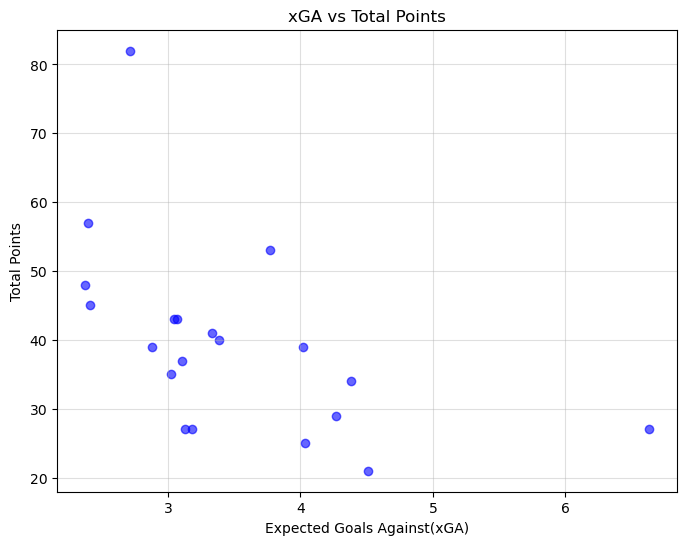

In [27]:
#Scatter plot to visualise correlation between xGA and Total Points
team = df.groupby("teamName").max(numeric_only=True)
corr = team.corr()["tot_points"].sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.scatter(team["xGA"],team["tot_points"],color="blue", alpha=0.6)
plt.xlabel("Expected Goals Against(xGA)")
plt.ylabel("Total Points")
plt.title("xGA vs Total Points")
plt.grid(True, alpha=0.4)
#This plot demonstrates that the top teams had the fewest xGA,except from the team with the third most points in this graph, who had almost double the other teams in the top five xGA
#The plots are attracted to the left side, indicating a negative correlation.The points are moderately close which most likely means the correlation is not high

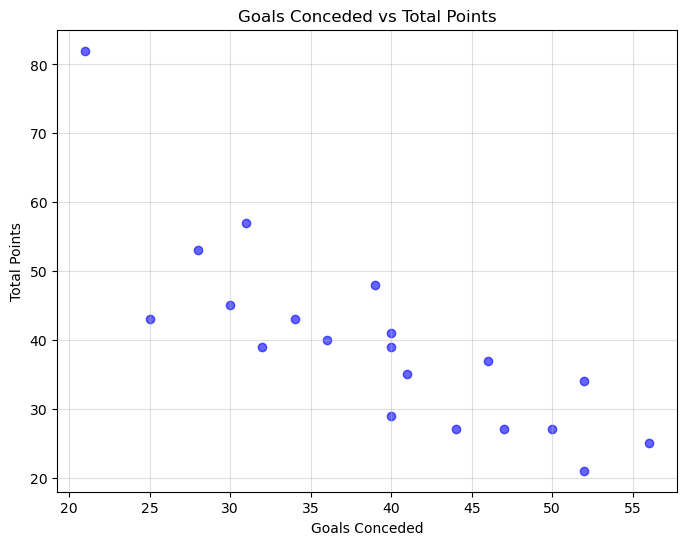

In [23]:
#Scatter plot to visualise correlation between Goals Conceded and Total Points
team = df.groupby("teamName").max(numeric_only=True)
corr = team.corr()["tot_points"].sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.scatter(team["tot_con"],team["tot_points"],color="blue", alpha=0.6)
plt.xlabel("Goals Conceded")
plt.ylabel("Total Points")
plt.title("Goals Conceded vs Total Points")
plt.grid(True, alpha=0.4)
#The scatter plot demonstrates that the teams with the most points generally conceded few goals, but the team with the fourth highest points conceded more goals than half the other teams, this metric could still make sense depending on the number of goals scored.
# There is a high separation between the plots towards the left side, indicating a high negative correlation

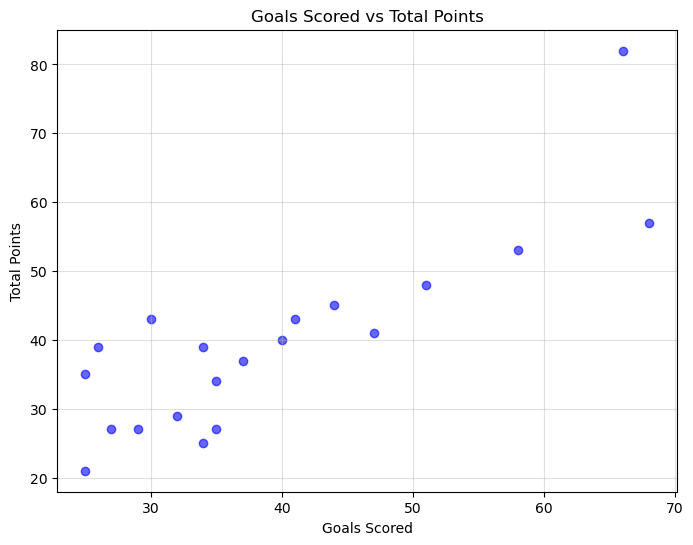

In [24]:
#Scatter plot to visualise correlation between Goals Scored and Total Points
team = df.groupby("teamName").max(numeric_only=True)
corr = team.corr()["tot_points"].sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.scatter(team["tot_goal"],team["tot_points"],color="blue", alpha=0.6)
plt.xlabel("Goals Scored")
plt.ylabel("Total Points")
plt.title("Goals Scored vs Total Points")
plt.grid(True, alpha=0.4)
#Plots shifting to the right, which means it is a positive correlation

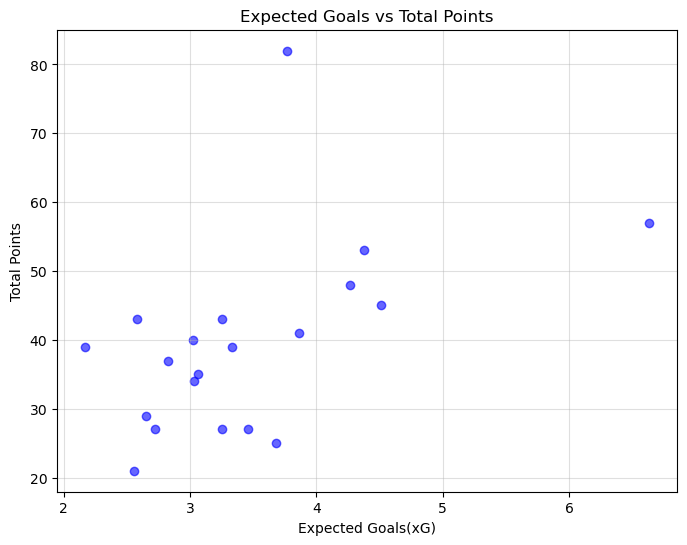

In [25]:
#Scatter plot to visualise correlation between xG and Total Points
team = df.groupby("teamName").max(numeric_only=True)
corr = team.corr()["tot_points"].sort_values(ascending=False)
plt.figure(figsize=(8,6))
plt.scatter(team["xG"],team["tot_points"],color="blue", alpha=0.6)
plt.xlabel("Expected Goals(xG)")
plt.ylabel("Total Points")
plt.title("Expected Goals vs Total Points")
plt.grid(True, alpha=0.4)
#Plots shifting to the right with the team with the most points having slightly less xG than six other teams but xG was still high with positive correlation

In [ ]:
#Conclusion: From the analysis 
#Goals scored and goals conceded had a high positive and negative correlation with total points respectively
#This could indicate that these two factors contributed to success the most
# xG and xGA also contributed to teams success but less so than the other two metrics